# Location Selection

In [1]:
from desdeo.problem import Constant, Variable, Problem, Objective, VariableTypeEnum, Constraint, TensorConstant, TensorVariable, ConstraintTypeEnum
import numpy as np

# These are to just suppress warnings in the outputs of the example
import warnings

warnings.filterwarnings("ignore")

## Model inputs


In [2]:

# Mininum expected attendance to be worth visiting 
min_att = 15

# Cost constants
# The current gas costs ($/gallon)
raw_dollars_per_gallon = 3.00

# The efficiency of the vehicle (miles/gallon)
raw_mpg = 6.0
# How long the event is (hours)
hours_per_event = 4
driver_salary_per_hour = 19
raw_driver_cost_per_trip = hours_per_event * driver_salary_per_hour

# Food desert threshold (miles) (TODO this should be in minutes)
raw_food_desert_threshold = 15




## Helper functions

In [3]:

def plot_cities(cities, marker_downscale_factor):

    margin = 0.05

    # Plot the cities on a Cartesian coordinate system
    city_coords = cities.loc[:,["lat", "long"]].values
    x_coords, y_coords = zip(*city_coords)

    plt.figure(figsize=(8, 8))
    plt.scatter(x_coords, y_coords, color='blue', s=cities.loc[:,"pop"]/marker_downscale_factor)
    
    for idx, city in cities.iterrows():
        plt.annotate(city["city"], (city["lat"], city["long"]), textcoords="offset points", xytext=(0,10), ha='center')


    min_x = min(x_coords) - margin
    max_x = max(x_coords) + margin
    min_y = min(y_coords) - margin
    max_y = max(y_coords) + margin

    plt.title('Mobile Clinic Service Region')
    plt.xlabel('Lat')
    plt.ylabel('Long')
    plt.xlim(min_x, max_x)
    plt.ylim(min_y, max_y)
    plt.grid()
    plt.show()

## Load and process Constants

In [4]:
from slugify import slugify
import pandas as pd

def no_nan(val):
    if pd.isna(val):
        return ""
    else:
        return str(val)

home = "Ada"
# Read the adjacency matrix (distance in miles)
adjDist = pd.read_csv("adjacencyMatrixDist.csv", index_col=0)
dist2home = adjDist.loc[:,[home]].rename(columns={home:"dist2home"})
dist2home.index.name = "city"
display(dist2home)

# Read the adjacency matrix (travel time in minutes)
adjTTime = pd.read_csv("adjacencyMatrixTravelTime.csv", index_col=0)
display(adjTTime)

# Read the cities 
cities = pd.read_csv("cities.csv")
events = pd.read_csv("events.csv")


,dist2home
city,
Ada,0.0
Lima,16.2
Kenton,15.5
Delphos,31.8
Bluffton,12.0
Spencerville,30.8
Elida,23.5
Forest,18.4
Alger,5.4


,Ada,Alger,Bluffton,Cairo,Columbus Grove,Continental,Cridersville,Delphos,Dunkirk,Elida,...,Mount Victory,New Bremen,New Knoxville,Ottawa,Ottoville,Pandora,Saint Marys,Spencerville,Wapakoneta,Waynesfield
Ada,0,9,16,20,25,48,28,34,16,30,...,34,52,46,34,37,26,45,43,36,25
Alger,9,0,22,26,31,54,29,40,20,35,...,33,53,46,40,43,32,46,45,36,19
Bluffton,16,22,0,17,15,39,25,31,23,27,...,48,49,42,23,34,13,42,40,32,32
Cairo,21,26,17,0,15,39,20,18,27,13,...,48,44,38,17,34,13,37,26,28,28
Columbus Grove,26,31,15,9,0,26,26,24,32,20,...,57,50,43,9,22,8,43,34,33,33
Continental,48,53,40,30,25,0,49,30,54,33,...,80,68,64,19,21,32,58,42,56,56
Cridersville,28,29,25,21,26,49,0,29,39,17,...,49,30,23,35,34,30,23,18,13,17
Delphos,34,39,31,18,24,30,29,0,40,12,...,66,40,35,32,11,33,30,14,33,42
Dunkirk,16,20,23,27,32,54,39,41,0,36,...,28,63,56,41,44,33,56,50,46,36
Elida,30,35,26,13,21,33,17,12,36,0,...,61,41,33,28,17,29,32,16,24,33


In [5]:
# Create event table
events = pd.merge(cities, events, on="city")
events.loc[:,"expectedAttendance"] = (events.loc[:,"pop"] * events.loc[:,"attendanceRate"]).astype(int)

events.loc[:, "event_id"] = events.apply(lambda row: slugify(f'{row["city"]} {row["site"]} {no_nan(row["event"])}'), axis=1)

# Add the distance to home for each event 
events = pd.merge(events, dist2home, on="city")

display(events)

,city,lat,long,pop,site,event,attendanceRate,expectedAttendance,event_id,dist2home
0,Ada,40.768056,-83.825278,5334,Public Library,NaN,0.002,10,ada-public-library,0.0
1,Alger,40.709722,-83.844167,837,Community Center,Food Commodities,0.002,1,alger-community-center-food-commodities,5.4
2,Alger,40.709722,-83.844167,837,Community Center,Community Dinner,0.002,1,alger-community-center-community-dinner,5.4
3,Bluffton,40.889444,-83.879167,3967,Bluffton Public Library,NaN,0.002,7,bluffton-bluffton-public-library,12.0
4,Cairo,40.830833,-84.084444,517,Public Library,NaN,0.002,1,cairo-public-library,18.6
5,Delphos,40.861111,-84.350000,7117,Public Library,NaN,0.002,14,delphos-public-library,31.8
6,Dunkirk,40.788056,-83.642778,774,HN Community Center,Community Meal,0.002,1,dunkirk-hn-community-center-community-meal,10.6
7,Elida,40.786667,-84.198889,1923,Public Library,NaN,0.002,3,elida-public-library,23.5
8,Forest,40.805000,-83.511667,1350,Public Library,NaN,0.002,2,forest-public-library,18.4
9,Kenton,40.646667,-83.622500,7947,Seton Hall,NaN,0.002,15,kenton-seton-hall,15.5


### Plot cities

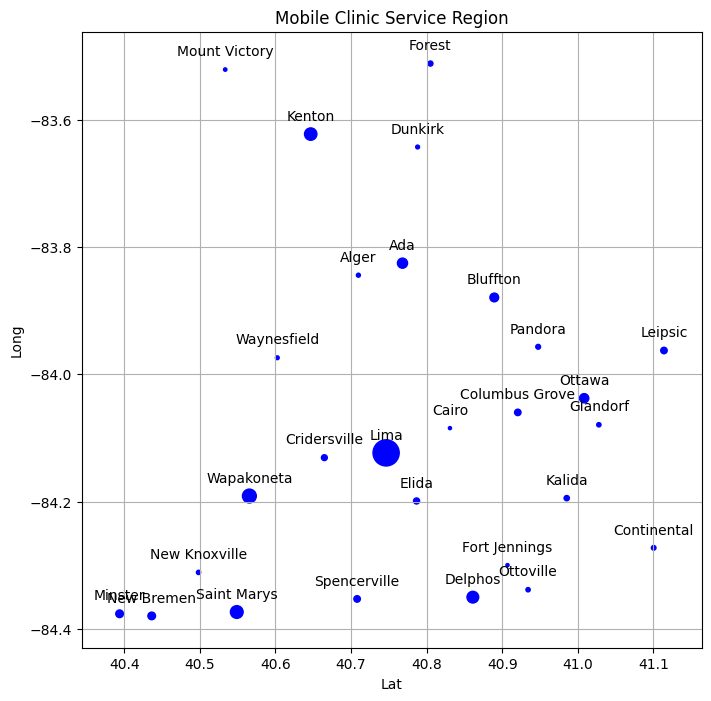

In [6]:
%matplotlib inline 
import matplotlib.pyplot as plt

city_coords = cities.loc[:, ["lat","long"]].values

marker_downscale_factor = 100

plot_cities(cities, marker_downscale_factor)

### Close cities for events

In [7]:

close_cities = adjTTime < raw_food_desert_threshold
event2city = events.loc[:,["city", "event_id"]].merge(close_cities, left_on="city", right_index=True)
event2city = (event2city.iloc[:,2:].values).astype(int)
e_adj_raw = event2city.T
display(event2city.T.shape)
e_adj_raw_list = e_adj_raw.tolist()
e_adj_raw_list

(28, 18)

[[1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
 [1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
 [0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
 [0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0],
 [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
 [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
 [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
 [0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
 [0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0],
 [0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0],
 [0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0],
 [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
 [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
 [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
 [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1],
 [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
 [0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0],
 [0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

In [8]:
event_dist2home = events.loc[:,["dist2home"]].T.values
event_dist2home_list = event_dist2home.tolist()

## Constants

In [9]:
event_count = events.shape[0]

# Expected attenance 
raw_attendance = events.loc[:,["expectedAttendance"]] 
raw_over_attendance = (raw_attendance < min_att).astype(int)

# How many people to expect to attend each event
ea = TensorConstant(name="Expected attendance",
                                 symbol="ea", 
                                 type="int",
                                 shape=raw_attendance.T.shape,
                                 values=raw_attendance.T.values.tolist())
display(ea)

# How many events are expected to be over attended? 
eoa = TensorConstant(name="Expected over attendance", 
                    symbol="eoa", 
                    type="integer",
                    shape=raw_over_attendance.T.shape,
                    values=raw_over_attendance.T.values.tolist())

display(eoa)

# Distance to home 
ed2h = TensorConstant(name="The distance to drive from home to event", 
                    symbol="ed2h", 
                    type="real",
                    shape=event_dist2home.shape,
                    values=event_dist2home_list)
display(ed2h)

mpg = Constant(name="Miles per gallon (miles/gallon)", 
               symbol="mpg", 
               type="real",
               value=raw_mpg)

display(mpg)
dpg = Constant(name="Dollars per gallon ($/gallon)", 
               symbol="dpg", 
               type="real",
               value=raw_dollars_per_gallon)

display(dpg)
dcpt = Constant(name="Driver cost per trip ($)", 
                                symbol="dcpt", 
                                type="real", 
                                value=raw_driver_cost_per_trip)

display(dcpt)

# Event adjacency to cities
e_adj = TensorConstant(name="Event adjacency to cities", 
                      symbol="e_adj", 
                      shape=e_adj_raw.shape,
                      values=e_adj_raw_list)
display(e_adj)

city_pops = TensorConstant(name="City populations", 
                           symbol="cpop", 
                           shape=[cities.shape[0],1],
                           values=cities.loc[:,["pop"]].values.tolist()
                           )

display(city_pops)

total_pop = Constant(name="Total population of interest", 
                     symbol="tpop", 
                     type="real",
                     value=float(sum(cities.loc[:,"pop"])))

display(total_pop)


TensorConstant(name='Expected attendance', symbol='ea', shape=[1, 18], values=['List', ['List', 10, 1, 1, 7, 1, 14, 1, 3, 2, 15, 15, 15, 71, 71, 71, 71, 71, 1]])

TensorConstant(name='Expected over attendance', symbol='eoa', shape=[1, 18], values=['List', ['List', 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1]])

TensorConstant(name='The distance to drive from home to event', symbol='ed2h', shape=[1, 18], values=['List', ['List', 0.0, 5.4, 5.4, 12.0, 18.6, 31.8, 10.6, 23.5, 18.4, 15.5, 15.5, 15.5, 16.2, 16.2, 16.2, 16.2, 16.2, 24.7]])

Constant(name='Miles per gallon (miles/gallon)', symbol='mpg', value=6.0)

Constant(name='Dollars per gallon ($/gallon)', symbol='dpg', value=3.0)

Constant(name='Driver cost per trip ($)', symbol='dcpt', value=76)

TensorConstant(name='Event adjacency to cities', symbol='e_adj', shape=[28, 18], values=['List', ['List', 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], ['List', 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], ['List', 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], ['List', 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0], ['List', 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], ['List', 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], ['List', 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], ['List', 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], ['List', 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0], ['List', 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0], ['List', 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0], ['List', 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], ['List', 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], ['List', 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], ['List'

TensorConstant(name='City populations', symbol='cpop', shape=[28, 1], values=['List', ['List', 5334], ['List', 837], ['List', 3967], ['List', 517], ['List', 2160], ['List', 1102], ['List', 1791], ['List', 7117], ['List', 774], ['List', 1923], ['List', 1350], ['List', 525], ['List', 969], ['List', 1455], ['List', 7947], ['List', 2177], ['List', 35579], ['List', 3046], ['List', 601], ['List', 3034], ['List', 946], ['List', 4456], ['List', 966], ['List', 1204], ['List', 8397], ['List', 2198], ['List', 9957], ['List', 749]])

Constant(name='Total population of interest', symbol='tpop', value=111078.0)

## Variables

In [10]:
ev = TensorVariable(
  name="Events visited",
  symbol="ev",
  variable_type=VariableTypeEnum.integer,
  shape=[events.shape[0],1],
  lowerbounds=0,
  upperbounds=1,
  initial_value=0)

display(ev)

cover = TensorVariable(
    name="Coverage of cities",
    symbol="cover", 
    variable_type=VariableTypeEnum.integer,
    shape=[adjTTime.shape[0],1],
    lowerbounds=0,
    upperbounds=1,
    initial_values=0)

cover



TensorVariable(name='Events visited', symbol='ev', variable_type=<VariableTypeEnum.integer: 'integer'>, shape=[18, 1], lowerbounds=0, upperbounds=1, initial_values=None)

TensorVariable(name='Coverage of cities', symbol='cover', variable_type=<VariableTypeEnum.integer: 'integer'>, shape=[28, 1], lowerbounds=0, upperbounds=1, initial_values=0)

## Constraints

In [11]:
# ev = [18, 1]
# cover [28, 1]
# e_adj [28, 18]
# [28, 18] . [18, 1] = [28, 1]


g = Constraint(
      name="Desert constraint",
      symbol="c",
      func="cover-e_adj@ev",
      cons_type=ConstraintTypeEnum.LTE,
      is_convex=False,
      is_linear=True,
      is_twice_differentiable=True)

## Objective

In [12]:
# Total patients seen 
total_patients = Objective(
    name = "Maximize total patients visited",
    symbol = "f_1", 
    maximize = True,
    is_twice_differentiable=True,
    func = "Sum(ea@ev)"
)

# Overstaffed events
over_staffed_events = Objective(
    name = "Minimize the number of overstaffed events",
    symbol = "f_2",
    maximize = False,
    is_twice_differentiable=True,
    func = "Sum(eoa@ev)"
)

# Cost of events
costs = Objective(
    name = "Minimize costs",
    symbol = "f_3",
    maximize = False,
    is_twice_differentiable=True,
    func = "(Sum(ed2h@ev)/mpg)*dpg + Sum(ev)*dcpt"
)


# cpop: [1, 28]
# cover: [28, 1]
# 
coverage = Objective(
    name = "Maximize coverage of region", 
    symbol = "f_4", 
    maximize = True, 
    is_twice_differentiable=True,
    func = "Sum(cover*cpop)/tpop"
)



## Problem

In [13]:
prob = Problem(
        name="Simple site selection",
        description="Simple implementation of the site selection problem",
        type="linear",
        constraints=[g],
        constants=[eoa, ea, ed2h, mpg, dpg, dcpt, e_adj, city_pops, total_pop],
        variables=[ev, cover],
        objectives=[total_patients, over_staffed_events, costs, coverage]
    )

## Ideal/nadir

In [14]:
# f_1 ideal is seeing all patients, nadir is seeing no patients
all_patients = int(np.sum(events.loc[:,"expectedAttendance"]))

# f_2 ideal is having no over staffed events
# f_2 naird is having visiting all locations with over staffed events
all_ose = int(np.sum(raw_over_attendance))


# How many miles are driven/gas costs
max_dist = events.loc[:,"dist2home"].sum()
total_gas_cost = (max_dist / raw_mpg) * raw_dollars_per_gallon
driver_cost = events.shape[0]*raw_driver_cost_per_trip
max_costs = float(driver_cost + total_gas_cost)

prob = prob.update_ideal_and_nadir(
    new_ideal={
        "f_1": all_patients,
        "f_2": 0, 
        "f_3": 0, 
        "f_4": 1.0
        }, 
    new_nadir={
        "f_1": 0,
        "f_2": all_ose,
        "f_3": max_costs, 
        "f_4": 0
        }
    )


print(f"Ideal values: {prob.get_ideal_point()}")
print(f"Nadir values: {prob.get_nadir_point()}")


Ideal values: {'f_1': 441, 'f_2': 0, 'f_3': 0, 'f_4': 1.0}
Nadir values: {'f_1': 0, 'f_2': 10, 'f_3': 1506.95, 'f_4': 0}


## RPM solver


In [15]:
from desdeo.mcdm.reference_point_method import rpm_solve_solutions

reference_point = {"f_1": 200, "f_2": 2, "f_3": 300, "f_4": 0.40}
display(prob)
raw_results = rpm_solve_solutions(prob, reference_point=reference_point)


Problem(name='Simple site selection', description='Simple implementation of the site selection problem', constants=[TensorConstant(name='Expected over attendance', symbol='eoa', shape=[1, 18], values=['List', ['List', 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1]]), TensorConstant(name='Expected attendance', symbol='ea', shape=[1, 18], values=['List', ['List', 10, 1, 1, 7, 1, 14, 1, 3, 2, 15, 15, 15, 71, 71, 71, 71, 71, 1]]), TensorConstant(name='The distance to drive from home to event', symbol='ed2h', shape=[1, 18], values=['List', ['List', 0.0, 5.4, 5.4, 12.0, 18.6, 31.8, 10.6, 23.5, 18.4, 15.5, 15.5, 15.5, 16.2, 16.2, 16.2, 16.2, 16.2, 24.7]]), Constant(name='Miles per gallon (miles/gallon)', symbol='mpg', value=6.0), Constant(name='Dollars per gallon ($/gallon)', symbol='dpg', value=3.0), Constant(name='Driver cost per trip ($)', symbol='dcpt', value=76), TensorConstant(name='Event adjacency to cities', symbol='e_adj', shape=[28, 18], values=['List', ['List', 1, 1, 1, 0, 0

SetProduct.subsets() to get the operator arguments.  (deprecated in 5.7)
(called from
C:\Users\i-kropp\AppData\Local\DESDEO\desdeo\problem\json_parser.py:455)
SetProduct.subsets() to get the operator arguments.  (deprecated in 5.7)
(called from
C:\Users\i-kropp\AppData\Local\DESDEO\desdeo\problem\json_parser.py:456)
SetProduct.subsets() to get the operator arguments.  (deprecated in 5.7)
(called from
C:\Users\i-kropp\AppData\Local\DESDEO\desdeo\problem\json_parser.py:461)
SetProduct.subsets() to get the operator arguments.  (deprecated in 5.7)
(called from
C:\Users\i-kropp\AppData\Local\DESDEO\desdeo\problem\json_parser.py:469)
SetProduct.subsets() to get the operator arguments.  (deprecated in 5.7)
(called from
C:\Users\i-kropp\AppData\Local\DESDEO\desdeo\problem\json_parser.py:470)
SetProduct.subsets() to get the operator arguments.  (deprecated in 5.7)
(called from
C:\Users\i-kropp\AppData\Local\DESDEO\desdeo\problem\json_parser.py:471)
SetProduct.subsets() to get the operator argum

## Clean up results

In [16]:
# Transform objectives
results = pd.DataFrame([r.optimal_objectives for r in raw_results])
results = results.rename(columns={
                "f_1": "Total patients served", 
                "f_2": "Number of overstaffed events", 
                "f_3": "Total costs", 
                "f_4": "Population with access (%)"})
results[["Total patients served", "Number of overstaffed events"]] =  results[["Total patients served", "Number of overstaffed events"]].astype(int)
results[["Population with access (%)"]] = (results[["Population with access (%)"]]*100.0).round(2)


# Form the decision variables into event and coverage strings
raw_events = np.array([ r.optimal_variables['ev'] for r in raw_results ]).squeeze().astype(bool)
raw_coverage = np.array([ r.optimal_variables['cover'] for r in raw_results ]).squeeze().astype(bool)

events_visited = []
for evb in raw_events: 
    events_visited.append("\n".join(events.loc[evb, "event_id"].values))

cities_covered = [] 
for cc in raw_coverage: 
    cities_covered.append("\n".join(cities.loc[cc,"city"].values))

results["Events Visited"] = events_visited
results["Cities covered"] = cities_covered

results

,Total patients served,Number of overstaffed events,Total costs,Population with access (%),Events Visited,Cities covered
0,223,1,328.30,39.78,ada-public-library\nlima-mercy-health-thrift\n...,Ada\nAlger\nCairo\nElida\nLima
1,228,0,336.05,41.92,kenton-ymca\nlima-mercy-health-thrift\nlima-ha...,Cairo\nElida\nKenton\nLima\nMount Victory
2,223,1,328.30,39.78,ada-public-library\nlima-mercy-health-thrift\n...,Ada\nAlger\nCairo\nElida\nLima
3,228,0,336.05,41.92,kenton-ymca\nlima-mercy-health-thrift\nlima-ha...,Cairo\nElida\nKenton\nLima\nMount Victory
4,402,4,835.45,63.77,ada-public-library\nbluffton-bluffton-public-l...,Ada\nAlger\nBluffton\nCairo\nDelphos\nDunkirk\...


In [19]:
import pandas as pd
import folium
from IPython.display import display

# TODO add to requirements.txt if this works

# Create a base map
m = folium.Map(location=[cities['lat'].mean(), cities['long'].mean()], zoom_start=7)

# Function to determine marker size based on population
def get_marker_size(population):
    return max(5, population / 1000)  # Adjust the divisor to scale marker size

# Add cities to the map
for _, row in cities.iterrows():
    folium.CircleMarker(
        location=(row['lat'], row['long']),
        radius=get_marker_size(row['pop']),
        color='blue',
        fill=True,
        fill_color='blue',
        fill_opacity=0.6,
        popup=f"{row['city']}: {row['pop']} people"
    ).add_to(m)

# Display the map inline in the Jupyter Notebook
display(m)